# Spam Message Classification Using NLP

## Project Category
Natural Language Processing (NLP)

---

## Objective

The objective of this project is to classify text messages as spam or ham (non-spam) using Natural Language Processing (NLP) and machine learning techniques.

This project aims to:
- preprocess textual data,
- apply TF-IDF vectorization,
- train machine learning classification models,
- evaluate text classification performance,
- identify spam message patterns.

---

## Dataset Information

The dataset contains SMS messages labeled as:

- Spam
- Ham (non-spam)

The dataset is commonly used for NLP and text classification tasks.

---

## Algorithms Used

- TF-IDF Vectorization
- Logistic Regression
- Naive Bayes
- Random Forest Classifier

---

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

---

## Project Workflow

1. Data Understanding
2. Text Cleaning
3. Text Vectorization
4. Train-Test Split
5. Model Training
6. Model Evaluation
7. Confusion Matrix
8. Conclusion

In [2]:
from google.colab import files

uploaded = files.upload()

Saving spam.csv to spam.csv


In [3]:
import pandas as pd

df = pd.read_csv(
    "spam.csv",
    encoding="latin-1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.tail()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN
5571,ham,Rofl. Its true to its name,NaN,NaN,NaN


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (5572, 5)

Columns:
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

Data Types:
v1            object
v2            object
Unnamed: 2    object
Unnamed: 3    object
Unnamed: 4    object
dtype: object

Missing Values:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

Duplicate Rows:
403


In [8]:
df.columns

Index(['v1', 'v2'], dtype='object')

In [9]:
df.columns = ["Label", "Message"]

In [10]:
df = df.drop_duplicates()

In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


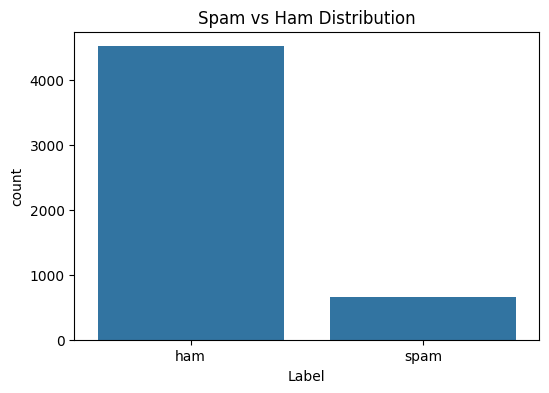

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x=df["Label"])

plt.title("Spam vs Ham Distribution")

plt.show()

In [13]:
!pip install imbalanced-learn

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df["Message"]
y = df["Label"]

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=3000)

X_tfidf = vectorizer.fit_transform(X)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train)

In [17]:
print(y_train.value_counts())
print(y_train_smote.value_counts())

Label
ham     3613
spam     522
Name: count, dtype: int64
Label
ham     3613
spam    3613
Name: count, dtype: int64


In [18]:
from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.ensemble import RandomForestClassifier

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)

import pandas as pd

In [20]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Naive Bayes":
        MultinomialNB(),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42 )}

In [22]:
df["Label"].unique()

array(['ham', 'spam'], dtype=object)

In [23]:
df["Label"] = df["Label"].map({
    "ham": 0,
    "spam": 1})

/tmp/ipykernel_867/1138284892.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Label"] = df["Label"].map({


In [24]:
df["Label"].unique()

array([0, 1])

In [25]:
X = df["Message"]

y = df["Label"]

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=3000)

X_tfidf = vectorizer.fit_transform(X)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [28]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train)

In [29]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42 )}

results = []

for model_name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)})

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.974855,0.920000,0.877863,0.898438
1,Naive Bayes,0.968085,0.831081,0.938931,0.881720
2,Random Forest,0.979691,0.966102,0.870229,0.915663


In [30]:
best_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42)

best_model.fit(
    X_train_smote,
    y_train_smote)

y_pred = best_model.predict(X_test)

In [31]:
best_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42)

best_model.fit(
    X_train_smote,
    y_train_smote)

y_pred = best_model.predict(X_test)

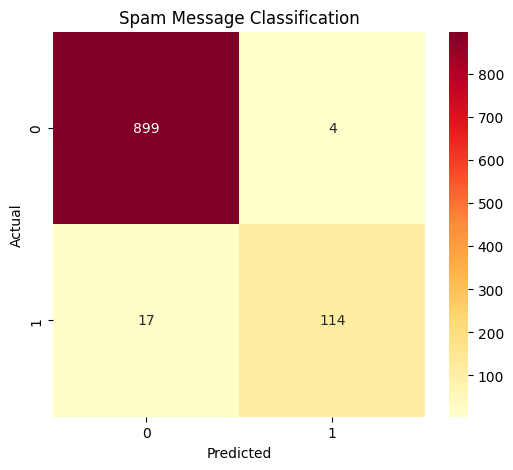

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlOrRd")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Spam Message Classification")

plt.show()

## Confusion Matrix Analysis

The confusion matrix shows that the Random Forest model achieved excellent spam classification performance.

### Results
- 899 ham messages were correctly classified.
- 114 spam messages were correctly detected.
- Only 4 ham messages were incorrectly classified as spam.
- 17 spam messages were missed by the model.

### Interpretation

The model demonstrates very strong overall performance with extremely low false positive predictions.

This is especially important in spam detection systems because legitimate messages should not be incorrectly blocked as spam.

The Random Forest model successfully balanced spam detection performance and classification reliability.